# XGBoost Baseline — Used Car Dynamic Pricing

本 notebook 使用处理后的特征数据训练 XGBoost 回归基线模型，并用 **MAE** 评估效果。

**Input:** `data/processed/train_fe.csv`  
**Outputs:** `models/xgb_model.pkl`, `outputs/xgb_validation_predictions.csv`

说明：Setup 单元会在 macOS 下自动加载 XGBoost 需要的 OpenMP 动态库。

## Setup

In [4]:
import ctypes
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# macOS 下系统 Python 需要先加载 OpenMP 动态库，否则 XGBoost 会报 libomp 错误
LIBOMP_PATH = PROJECT_ROOT / ".conda" / "lib" / "libomp.dylib"
if LIBOMP_PATH.exists():
    ctypes.CDLL(str(LIBOMP_PATH), mode=ctypes.RTLD_GLOBAL)

import xgboost as xgb
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "train_fe.csv"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "xgb_model.pkl"
PRED_PATH = OUTPUT_DIR / "xgb_validation_predictions.csv"

TEST_SIZE = 0.2
RANDOM_STATE = 42
EARLY_STOPPING_ROUNDS = 100

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["savefig.dpi"] = 150

## 1. Load processed dataset

In [5]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (150000, 49)


,SaleID,name,regDate,model,brand,bodyType,fuelType,gearbox,power,kilometer,...,km_per_year,power_bin,car_age_bin,brand_price_mean,brand_price_median,brand_price_std,brand_price_max,model_power_mean,model_power_std,model_count
0,0,736,20040402,30.0,6,1.0,0.0,0.0,60,12.5,...,1.041192,p0_60,a12_20,3611.840266,1800.0,4681.293524,59900,64.700256,31.990438,2342.0
1,1,2262,20030301,40.0,1,2.0,0.0,0.0,0,15.0,...,1.151724,p0_60,a12_20,9273.311947,6499.0,9369.631497,99900,140.859396,52.495875,4502.0
2,2,14874,20040403,115.0,15,1.0,0.0,0.0,163,12.5,...,1.041904,p140_200,a8_12,9858.582990,8500.0,5425.058140,45000,137.343042,40.963832,927.0
3,3,71865,19960908,109.0,10,0.0,0.0,1.0,193,15.0,...,0.768947,p140_200,a12_20,8470.804197,5400.0,8988.307535,98000,259.880829,102.059068,386.0
4,4,111080,20120103,110.0,5,1.0,0.0,0.0,68,5.0,...,1.192848,p60_100,a3_5,3306.349411,2300.0,3343.624586,31500,57.186004,23.085682,543.0


## 2. Define target and feature matrix

Remove `SaleID` (identifier) and `price` (target) from features. Drop raw datetime string columns (`regDate_dt`, `creatDate_dt`) because engineered calendar fields are already available.

In [6]:
TARGET = "price"
ID_COL = "SaleID"

y = df[TARGET]
sale_ids = df[ID_COL]

drop_cols = [ID_COL, TARGET, "regDate_dt", "creatDate_dt"]
X = df.drop(columns=drop_cols)

print(f"Features: {X.shape[1]} columns")
X.dtypes.value_counts()

Features: 45 columns


float64    32
int64      11
object      2
Name: count, dtype: int64

## 3. Encode categorical bins

`power_bin` and `car_age_bin` are ordinal buckets stored as strings. We map them to integer codes **fit on the training split only** (after the split below) to avoid leakage.

In [7]:
BIN_CAT_COLS = ["power_bin", "car_age_bin"]

for col in BIN_CAT_COLS:
    print(f"{col}: {X[col].nunique()} levels, missing={X[col].isna().sum()}")

power_bin: 6 levels, missing=0
car_age_bin: 7 levels, missing=11347


## 4. Train / validation split

`test_size=0.2`, `random_state=42` — 80% train, 20% validation.

In [8]:
X_train, X_val, y_train, y_val, id_train, id_val = train_test_split(
    X,
    y,
    sale_ids,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

def fit_bin_encoder(series: pd.Series) -> dict:
    """在训练集上学习分箱到整数的映射"""
    cats = sorted(series.dropna().astype(str).unique())
    return {c: i for i, c in enumerate(cats)}


def apply_bin_encoder(series: pd.Series, mapping: dict) -> pd.Series:
    """应用映射；验证集未见类别记为 NaN"""
    out = pd.Series(np.nan, index=series.index, dtype=float)
    mask = series.notna()
    out.loc[mask] = series.loc[mask].astype(str).map(mapping)
    return out


bin_encoders = {}
for col in BIN_CAT_COLS:
    mapping = fit_bin_encoder(X_train[col])
    bin_encoders[col] = mapping
    X_train[col] = apply_bin_encoder(X_train[col], mapping)
    X_val[col] = apply_bin_encoder(X_val[col], mapping)

print(f"Train: {X_train.shape[0]:,}  |  Val: {X_val.shape[0]:,}")

Train: 120,000  |  Val: 30,000


## 5–7. Train XGBoost with MAE metric and early stopping

| Hyperparameter | Value |
|----------------|-------|
| `n_estimators` | 2000 |
| `learning_rate` | 0.05 |
| `max_depth` | 8 |
| `subsample` | 0.8 |
| `colsample_bytree` | 0.8 |
| `objective` | `reg:squarederror` |

Optimization uses **`eval_metric='mae'`** with **early stopping** on the validation fold (stop if MAE does not improve for 100 rounds).

In [9]:
model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="mae",
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100,
)

print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-mae:4765.13277	validation_1-mae:4747.16783
[100]	validation_0-mae:536.40690	validation_1-mae:629.56387
[200]	validation_0-mae:458.92206	validation_1-mae:586.69976
[300]	validation_0-mae:411.14261	validation_1-mae:567.38419
[400]	validation_0-mae:373.24756	validation_1-mae:554.92653
[500]	validation_0-mae:342.81724	validation_1-mae:546.40464
[600]	validation_0-mae:317.32855	validation_1-mae:539.61730
[700]	validation_0-mae:295.10610	validation_1-mae:534.97321
[800]	validation_0-mae:274.71440	validation_1-mae:531.10616
[900]	validation_0-mae:257.20546	validation_1-mae:528.31713
[1000]	validation_0-mae:240.43435	validation_1-mae:525.58210
[1100]	validation_0-mae:226.03236	validation_1-mae:523.65685
[1200]	validation_0-mae:212.52396	validation_1-mae:522.15776
[1300]	validation_0-mae:200.24222	validation_1-mae:520.60964
[1400]	validation_0-mae:189.10771	validation_1-mae:519.36286
[1500]	validation_0-mae:177.93356	validation_1-mae:518.16194
[1600]	validation_0-mae:168.22239	

## 8. Train and validation MAE

In [10]:
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)

print(f"Train MAE:      {train_mae:,.2f}")
print(f"Validation MAE: {val_mae:,.2f}")

Train MAE:      136.20
Validation MAE: 514.23


## 9. Visualizations

- **Feature importance** — gain-based importance from the booster  
- **Prediction vs actual** — validation set (45° line = perfect prediction)

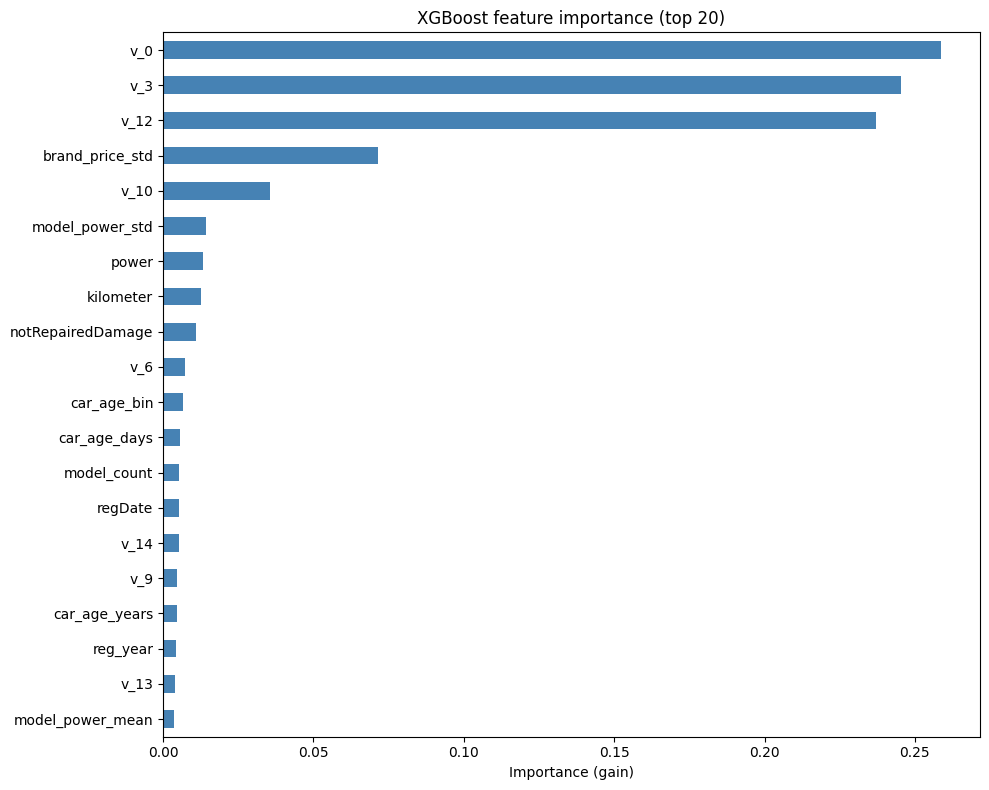

In [11]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns,
).sort_values(ascending=True)

top_n = 20
fig, ax = plt.subplots(figsize=(10, 8))
importance.tail(top_n).plot(kind="barh", ax=ax, color="steelblue")
ax.set_title(f"XGBoost feature importance (top {top_n})")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
fig.savefig(FIG_DIR / "xgb_feature_importance.png", bbox_inches="tight")
plt.show()

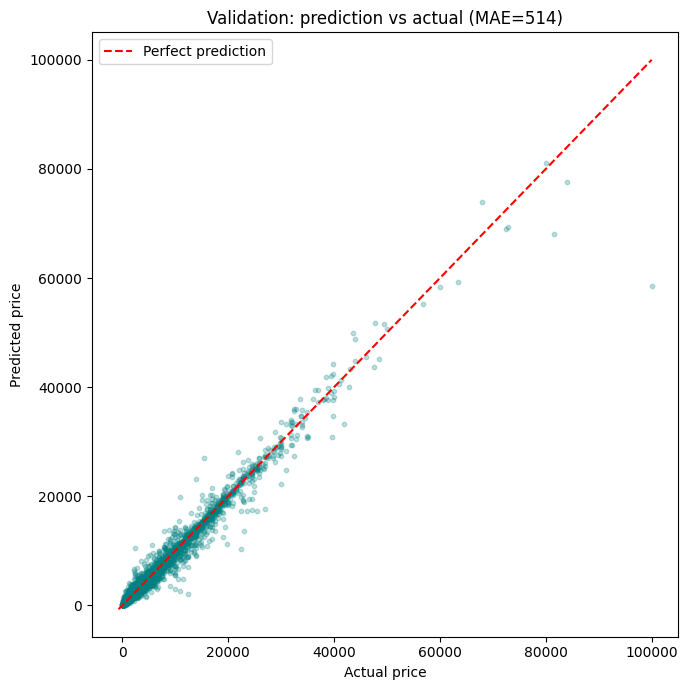

In [12]:
fig, ax = plt.subplots(figsize=(7, 7))
sample_idx = np.random.default_rng(RANDOM_STATE).choice(
    len(y_val), size=min(5000, len(y_val)), replace=False
)
ax.scatter(
    y_val.iloc[sample_idx],
    y_val_pred[sample_idx],
    alpha=0.25,
    s=10,
    c="teal",
)
lo = min(y_val.min(), y_val_pred.min())
hi = max(y_val.max(), y_val_pred.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Perfect prediction")
ax.set_xlabel("Actual price")
ax.set_ylabel("Predicted price")
ax.set_title(f"Validation: prediction vs actual (MAE={val_mae:,.0f})")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "xgb_pred_vs_actual.png", bbox_inches="tight")
plt.show()

## 10. Save model

Pickle bundle includes the fitted regressor and bin encoders for reproducible inference on new data.

In [13]:
artifact = {
    "model": model,
    "bin_encoders": bin_encoders,
    "feature_columns": X_train.columns.tolist(),
    "bin_cat_cols": BIN_CAT_COLS,
    "drop_cols": drop_cols,
    "train_mae": train_mae,
    "val_mae": val_mae,
}

with open(MODEL_PATH, "wb") as f:
    pickle.dump(artifact, f)

print(f"Saved: {MODEL_PATH}")

Saved: models/xgb_model.pkl


## 11. Save validation predictions

In [14]:
val_preds = pd.DataFrame(
    {
        "SaleID": id_val.values,
        "actual_price": y_val.values,
        "predicted_price": y_val_pred,
        "residual": y_val.values - y_val_pred,
        "abs_error": np.abs(y_val.values - y_val_pred),
    }
)
val_preds.to_csv(PRED_PATH, index=False)
print(f"Saved: {PRED_PATH}")
val_preds.head()

Saved: outputs/xgb_validation_predictions.csv


,SaleID,actual_price,predicted_price,residual,abs_error
0,59770,999,1019.208984,-20.208984,20.208984
1,21362,8500,8292.025391,207.974609,207.974609
2,127324,15500,15845.819336,-345.819336,345.819336
3,140509,10000,9978.173828,21.826172,21.826172
4,144297,2999,2963.989014,35.010986,35.010986


## Summary

Baseline XGBoost trained on engineered features with MAE early stopping. Review `reports/figures/xgb_*.png` for diagnostics and use the pickle artifact for batch scoring on a held-out test set (apply the same encoders and column order).